In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, io
import json
import logging
from warnings import filterwarnings

from data.lucas_descriptions import data_gdf_description
from utils.pipeline import run_pipeline
from utils.evaluation import evaluate_metrics
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage, HuggingFaceLLMClient
from utils.llm_api.query import QueryProvider, QueryType
from utils.extraction import (
    extract_json, extract_python_code, clean_python_code, 
    get_description_extraction_function_string, get_solution_function_string
)

## needed for running solution
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

filterwarnings("ignore")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
exec_needed_imports = """
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
"""

### Loading map of Europe

In [4]:
## load map from shapefile
world_gdf = gpd.read_file('data/europe/CNTR_RG_20M_2024_3035.shp')
world_gdf = world_gdf.to_crs(epsg=4326)
europe_gdf = world_gdf[(world_gdf['EU_STAT'] == 'T') | (world_gdf['CNTR_ID'] == 'UK')]
europe_gdf.loc[78, 'geometry'] = world_gdf[
    world_gdf['CNTR_ID'] == 'FR'
].iloc[0].geometry.geoms[3] ## dropping France's overseas teritories

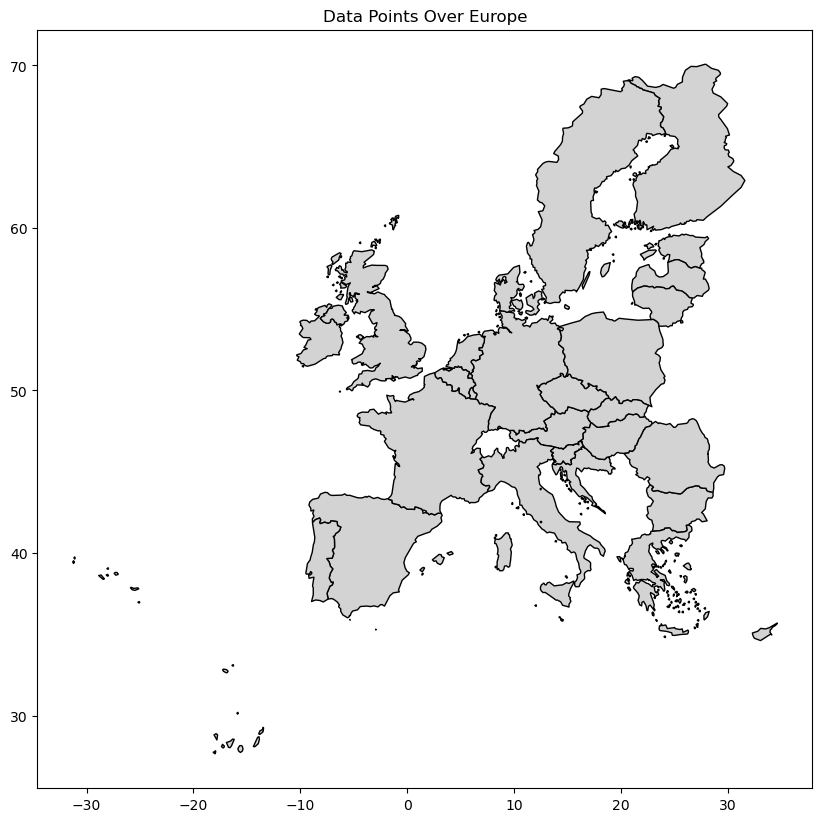

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray') 
plt.title("Data Points Over Europe")
plt.show()

In [6]:
buffer = io.StringIO()
europe_gdf.info(buf=buffer)
europe_gdf_description = buffer.getvalue()

### LLM setup

In [7]:
llm_client = GPT4AllClient()

In [8]:
available_models = llm_client.get_available_models()
available_models

['Reasoner v1',
 'DeepSeek-R1-Distill-Llama-8B',
 'Llama 3.2 3B Instruct',
 'Llama 3.2 1B Instruct',
 'Llama 3.1 8B Instruct 128k',
 'nomic-ai/nomic-embed-text-v1.5-GGUF']

In [9]:
MODEL_NAME_INSTRUCTOR = available_models[4]
MODEL_NAME_CODER = available_models[4]
MODEL_NAME_CORRECTOR = available_models[4]

client_instructor = GPT4AllClient(model_name=MODEL_NAME_CODER)
client_corrector = GPT4AllClient(model_name=MODEL_NAME_CORRECTOR)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [10]:
data_gdf = gpd.read_file("data/LUCAS_SOIL_2018_processed.gpkg", crs="EPSG:4326")

In [11]:
categorical_columns = ['Depth', 'NUTS_0', 'LC0_Desc', 'Country']

In [12]:
categorical_columns_values = ""
for categorical_column in categorical_columns:
    categorical_columns_values += f"{categorical_column}: {data_gdf[categorical_column].unique()}\n"

In [13]:
print(categorical_columns_values)

Depth: ['0-20 cm' '0-10 cm' '10-20 cm' '20-30 cm']
NUTS_0: ['AT' 'PT' 'ES' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'FR' 'UK' 'FI'
 'SE' 'SI' 'IT' 'HR' 'HU' 'IE' 'LT' 'LU' 'LV' 'MT' 'NL' 'PL' 'RO' 'SK']
LC0_Desc: ['Woodland' 'Cropland' 'Grassland' 'Bareland' 'Shrubland'
 'Artificial land' 'Wetlands' 'Water']
Country: ['Austria' 'Portugal' 'Spain' 'Belgium' 'Bulgaria' 'Cyprus'
 'Czech Republic' 'Germany' 'Denmark' 'Estonia' 'Greece' 'France'
 'United Kingdom' 'Finland' 'Sweden' 'Slovenia' 'Italy' 'Croatia'
 'Hungary' 'Ireland' 'Lithuania' 'Luxembourg' 'Latvia' 'Malta'
 'Netherlands' 'Poland' 'Romania' 'Slovakia']



In [14]:
model_id = MODEL_NAME_CODER
BASE_QUERY_DIR = './data/user_query_adjusted/'
BASE_CORRECT_RESULT_DIR = './data/correct_results/'
BASE_GENERATED_DIR = f'./data/generated/{model_id}/'
BASE_METRICS_DIR = f'./data/metrics/{model_id}/'

In [15]:
def exec_solution(solution_function_string):
    if solution_function_string is None:
        print("No solution provided.")
        return
    
    local_scope = {}
    exec(
        exec_needed_imports + "\n" + \
        solution_function_string + "\n\n" + \
        "solve(data_gdf, europe_gdf)", 
        globals(), local_scope
    )

In [16]:
def run_test(objective: str):
    solution_function_string = None
    try:
        solution_function_string = run_pipeline(
            objective=objective,
            client_instructor=client_instructor,
            client_corrector=client_corrector,
            client_coder=client_coder,
            data_gdf=data_gdf,
            data_gdf_description=data_gdf_description,
            europe_gdf=europe_gdf,
            europe_gdf_description=europe_gdf_description,
            retry_count=3,
            categorical_columns_values=categorical_columns_values
        )
    except Exception as e:
        logging.error(e)
        
    if solution_function_string is None:
        try:
            solution_function_string = run_pipeline(
                objective=objective,
                client_instructor=client_instructor,
                client_corrector=client_corrector,
                client_coder=client_coder,
                data_gdf=data_gdf,
                data_gdf_description=data_gdf_description,
                europe_gdf=europe_gdf,
                europe_gdf_description=europe_gdf_description,
                retry_count=1,
                categorical_columns_values=categorical_columns_values
            )
        except Exception as e:
            logging.error(e)
            
    return solution_function_string
    

In [17]:
geo_queries = []
for query_type in ['geo']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        geo_queries.append(query)

# 1. query

In [28]:
geo_queries[0]

'Can you plot the locations of all points where the pH_CaCl2 is greater than 6 on a map, and save the image as a PNG file?'

2025-02-17 21:57:56,631 - Query finished successfully, response: 
```python
# Filter the data to include only rows where pH_CaCl2 is greater than 6
filtered_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]

# Create a new GeoDataFrame with the filtered data and geometry column
transformed_gdf = geopandas.GeoDataFrame(filtered_gdf, geometry=filtered_gdf.geometry)
```
2025-02-17 21:57:56,639 - Error while running transform query: name 'geopandas' is not defined
2025-02-17 21:58:02,707 - Query finished successfully, response: 
```python
# Import the necessary package for GeoDataFrame operations
import geopandas as gpd

# Filter the data to include only rows where pH_CaCl2 is greater than 6
filtered_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]

# Create a new GeoDataFrame with the filtered data and geometry column
transformed_gdf = gpd.GeoDataFrame(filtered_gdf, geometry=filtered_gdf.geometry)

# Save the transformed results to a PNG file (Note: This requires additional setup for visualization)
# You 

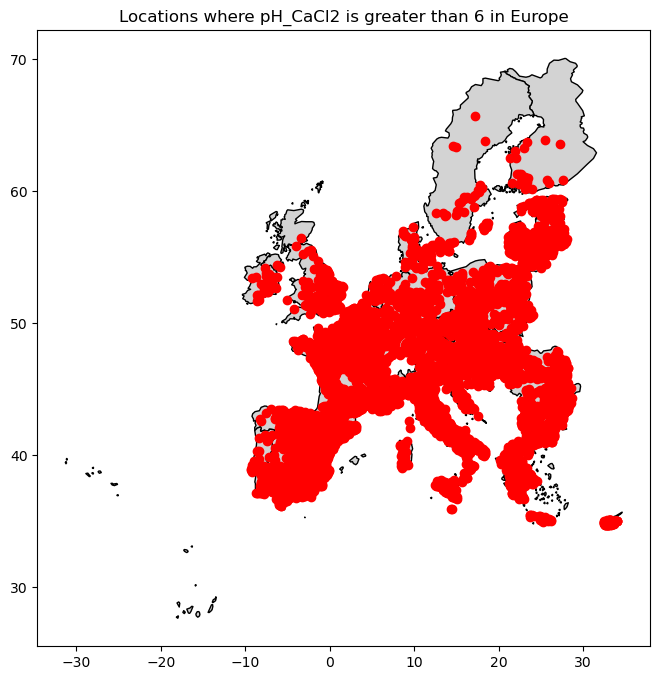

In [29]:
solution_function_string = run_test(geo_queries[0])

In [30]:
print(clean_python_code(solution_function_string))

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import the necessary package for GeoDataFrame operations
	import geopandas as gpd
	# Filter the data to include only rows where pH_CaCl2 is greater than 6
	filtered_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]
	# Create a new GeoDataFrame with the filtered data and geometry column
	transformed_gdf = gpd.GeoDataFrame(filtered_gdf, geometry=filtered_gdf.geometry)
	# Save the transformed results to a PNG file (Note: This requires additional setup for visualization)
	# You can use libraries like matplotlib or folium for this purpose.
	import matplotlib.pyplot as plt
	# Create a figure and axis object to plot the map
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set europe_gdf as the base of the map using the provided line
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Plot locations where pH_CaCl2 is greater than 6 on a map with markersize=1 and colored by LC0_Desc
	transformed_gdf.loc[transformed_gdf['pH_C

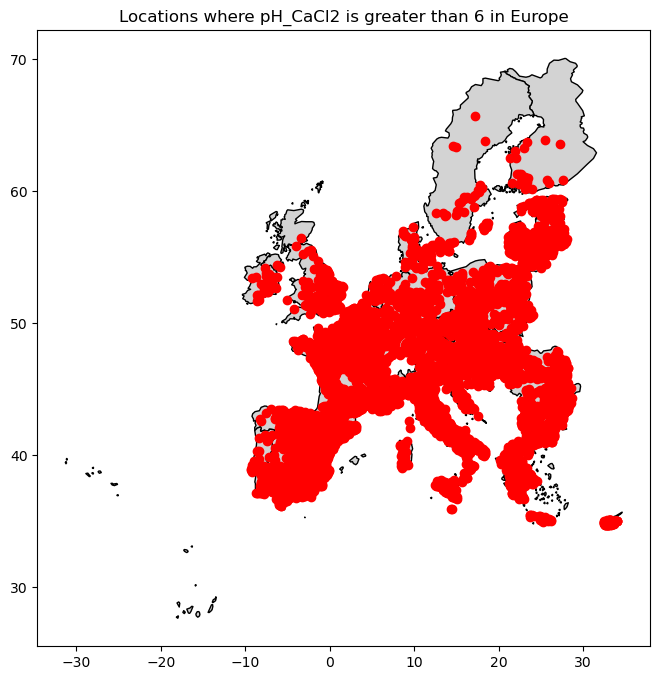

In [31]:
exec_solution(solution_function_string)

# 2. query

In [32]:
geo_queries[1]

"Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20 on the map, and save the map as a png."

2025-02-17 21:58:19,747 - Query finished successfully, response: 
```python
# Filter the data for LC0_Desc='Grassland' and LC0_Desc='Woodland'
filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
    
# Filter further to include only points where OC > 20
transformed_gdf = filtered_gdf[filtered_gdf['OC'] > 20]
```
2025-02-17 21:58:22,091 - Query finished successfully, response: 
map
2025-02-17 21:58:30,997 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots()

# Set the map of Europe as the base layer using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter 'transformed_gdf' to get only LC0_Desc='Grassland' and LC0_Desc='Woodland' points where OC>20
filtered_df = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
filtered_df = filtered_df[filtered_df[

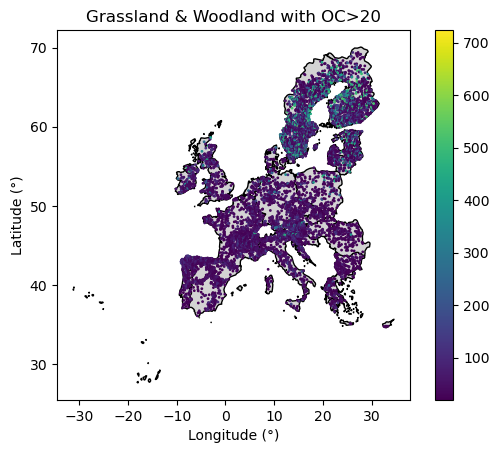

In [33]:
solution_function_string = run_test(geo_queries[1])

In [34]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data for LC0_Desc='Grassland' and LC0_Desc='Woodland'
	filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
	# Filter further to include only points where OC > 20
	transformed_gdf = filtered_gdf[filtered_gdf['OC'] > 20]
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots()
	# Set the map of Europe as the base layer using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter 'transformed_gdf' to get only LC0_Desc='Grassland' and LC0_Desc='Woodland' points where OC>20
	filtered_df = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
	filtered_df = filtered_df[filtered_df['OC']>20]
	# Plot the filtered data locations on top of the map as markers
	filtered_df.plot(ax=ax, column='OC', legend=True, markersize=1)
	# Set title 

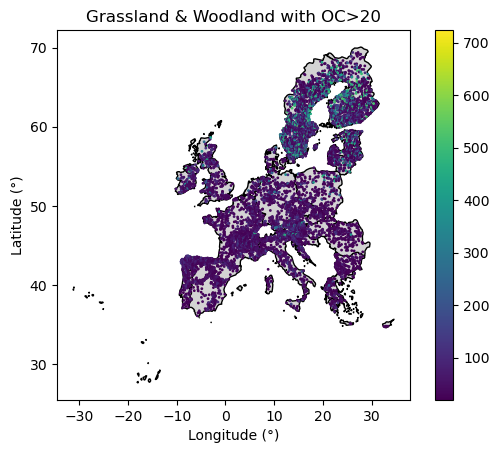

In [35]:
exec_solution(solution_function_string)

# 3. query

In [36]:
geo_queries[2]

'Can you plot the locations where LC0_Desc=Woodland on the map, and save the it as a PNG file?'

2025-02-17 21:58:39,375 - Query finished successfully, response: 
```python
# Filter the data where LC0_Desc equals 'Woodland'
woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Save the filtered GeoDataFrame to a new variable called transformed_gdf
transformed_gdf = woodland_gdf.copy()

# No further transformations are required, so we can proceed with plotting
```
2025-02-17 21:58:41,593 - Query finished successfully, response: 
map
2025-02-17 21:58:53,329 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter transformed data to only include locations where LC0_Desc=Woodland
woodlands = transformed_gdf[transformed_gdf['LC0_Desc'] == 'Woodland']

# Plot the woodlands as markers on the map
woodlands.plot(column='LC0_Desc', ax=ax, marker='o', color='gree

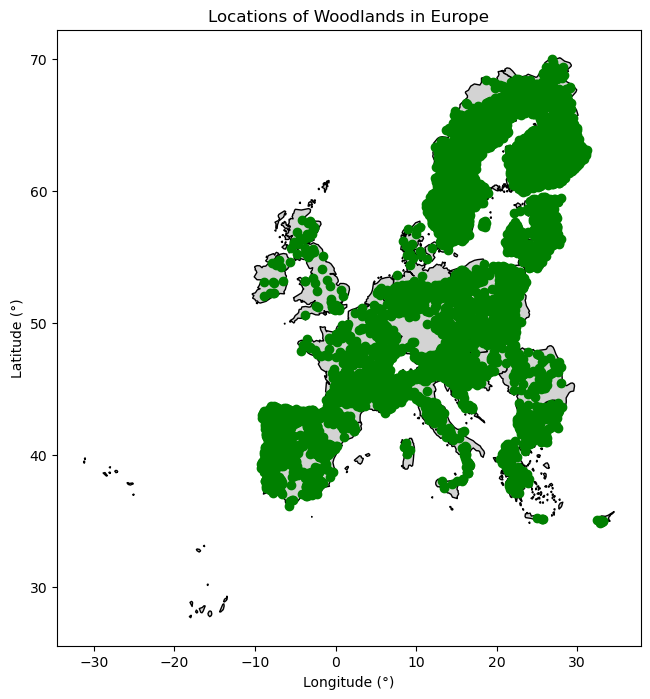

In [37]:
solution_function_string = run_test(geo_queries[2])

In [38]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data where LC0_Desc equals 'Woodland'
	woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']
	# Save the filtered GeoDataFrame to a new variable called transformed_gdf
	transformed_gdf = woodland_gdf.copy()
	# No further transformations are required, so we can proceed with plotting
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter transformed data to only include locations where LC0_Desc=Woodland
	woodlands = transformed_gdf[transformed_gdf['LC0_Desc'] == 'Woodland']
	# Plot the woodlands as markers on the map
	woodlands.plot(column='LC0_Desc', ax=ax, marker='o', color='green')
	# Set title and labels for better visualization
	ax.set_title('Locations of Woodlands in Europe')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel

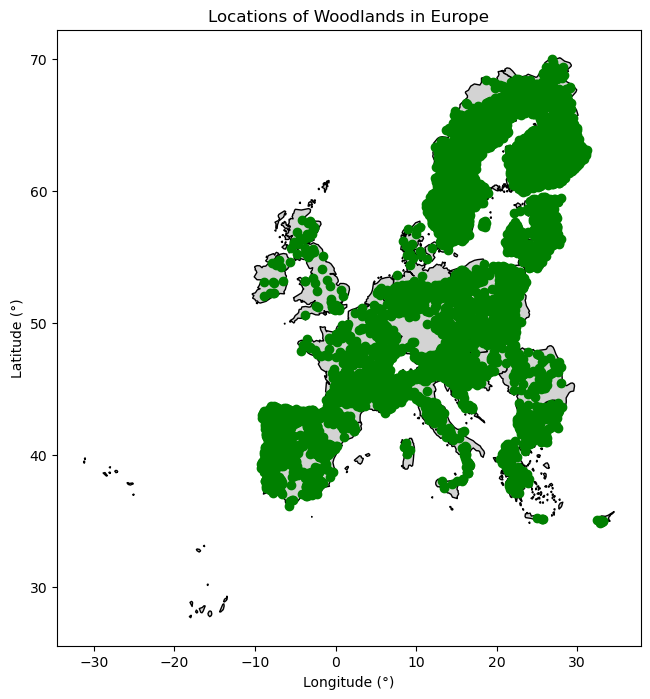

In [39]:
exec_solution(solution_function_string)

# 4. query

In [40]:
geo_queries[3]

'Plot all the points where LC0_Desc=Woodland and pH<6 on the map, and save the result as a png.'

2025-02-17 21:58:59,582 - Query finished successfully, response: 
```python
# Filter the data where LC0_Desc equals 'Woodland' and pH < 6
transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_H2O'] < 6)]
```
2025-02-17 21:59:01,891 - Query finished successfully, response: 
map
2025-02-17 21:59:10,144 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map of Europe using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter transformed data to plot only points where LC0_Desc=Woodland and pH<6
filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Woodland') & (transformed_gdf['pH_H2O'] < 6)]

# Plot the filtered locations as markers on top of the map
filtered_data.plot(ax=ax, marker='o', color='red', markersize=1)

# Set title and labels for better visualization
ax.set_title('Woodland area

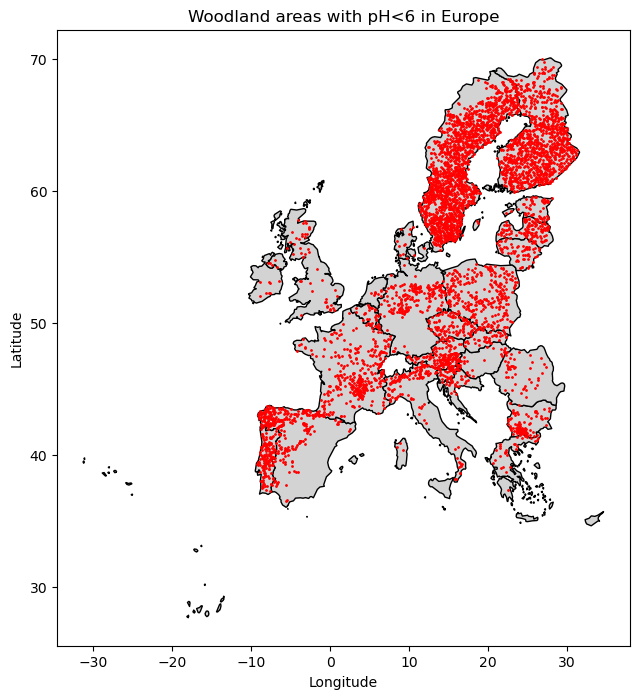

In [41]:
solution_function_string = run_test(geo_queries[3])

In [42]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data where LC0_Desc equals 'Woodland' and pH < 6
	transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_H2O'] < 6)]
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter transformed data to plot only points where LC0_Desc=Woodland and pH<6
	filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Woodland') & (transformed_gdf['pH_H2O'] < 6)]
	# Plot the filtered locations as markers on top of the map
	filtered_data.plot(ax=ax, marker='o', color='red', markersize=1)
	# Set title and labels for better visualization
	ax.set_title('Woodland areas with pH<6 in Europe')
	ax.set_xlabel('Longitude')
	ax.set_ylabel('Latitude')
	# Show the plot as a PNG file
	plt.savefig('woodland_pH_less_than_6.p

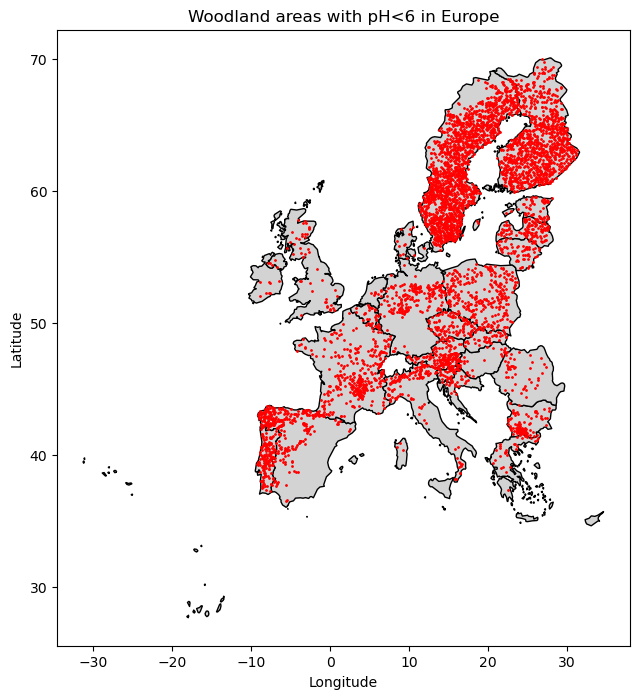

In [43]:
exec_solution(solution_function_string)

# 5. query

In [44]:
geo_queries[4]

'Can you use KMeans clustering to group geographic points based on latitude and longitude into three clusters, plot them on a map, and save the result as a PNG file?'

2025-02-17 21:59:18,442 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd
from sklearn.cluster import KMeans

# Create a new GeoDataFrame 'transformed_gdf' from the original data
transformed_gdf = data_gdf.copy()

# Select only relevant columns for clustering (latitude and longitude)
transformed_gdf['geometry'] = transformed_gdf.geometry.apply(lambda x: (x.y, x.x))  # Swap latitude and longitude

# Perform KMeans clustering on the selected points with three clusters
kmeans = KMeans(n_clusters=3)
transformed_gdf['cluster_label'] = kmeans.fit_predict(transformed_gdf[['geometry.1', 'geometry.0']])
```
2025-02-17 21:59:18,644 - Error while running transform query: "None of [Index(['geometry.1', 'geometry.0'], dtype='object')] are in the [columns]"
2025-02-17 21:59:28,341 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd
from sklearn.cluster import KMeans

# Select only relevant columns for

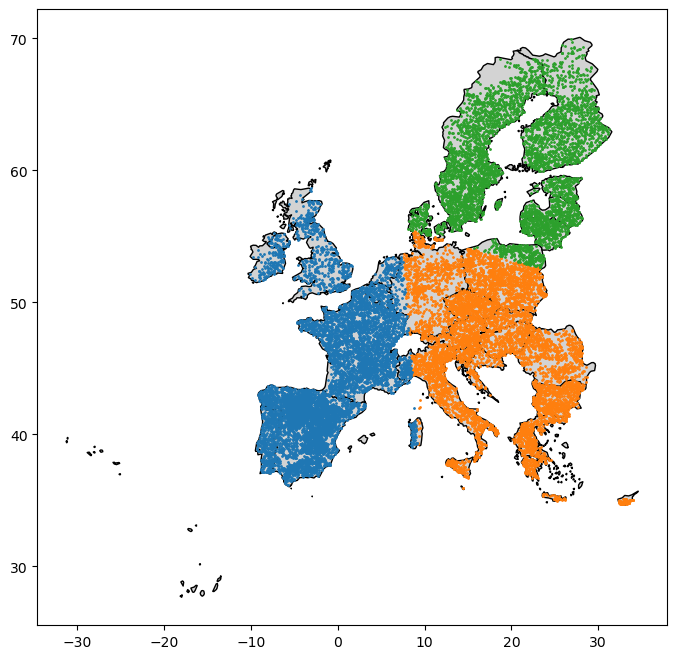

In [45]:
solution_function_string = run_test(geo_queries[4])

In [46]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary libraries
	import pandas as pd
	from sklearn.cluster import KMeans
	# Select the 'geometry' and 'TH_LAT', 'TH_LONG' columns from data_gdf to perform clustering on latitude and longitude values.
	transformed_gdf = data_gdf[['geometry', 'TH_LAT', 'TH_LONG']]
	# Initialize a K-Means model with 3 clusters
	kmeans_model = KMeans(n_clusters=3)
	# Fit the model to the transformed GeoDataFrame (latitude, longitude)
	kmeans_model.fit(transformed_gdf[['TH_LAT', 'TH_LONG']])
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the extent of the map to Europe
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Perform KMeans clustering on latitude and longitude columns in 'transformed_gdf'
	from sklearn.cluster import KMeans
	kmeans = KMeans(n_clusters=3)
	transformed_gdf['cluster'] = kmeans.fit_predict(transformed_gdf[['T

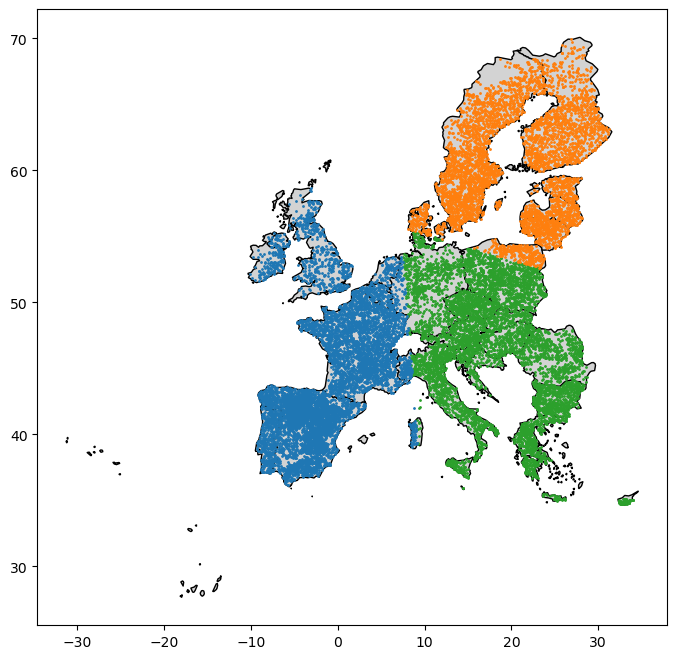

In [47]:
exec_solution(solution_function_string)

# 6. query

In [48]:
geo_queries[5]

'Can you create a map showing locations where potassium (K) levels are above the median, and save the map as a PNG file?'

In [49]:
solution_function_string = run_test(geo_queries[5])

2025-02-17 22:00:38,230 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to include only rows where K levels are above the median
median_K = data_gdf['K'].median()
transformed_gdf = data_gdf[data_gdf['K'] > median_K]

# Save the transformed GeoDataFrame to a new file (e.g., 'k_above_median.shp')
transformed_gdf.to_file('k_above_median.shp', driver='ESRI Shapefile')

# Alternatively, you can save it as PNG using Fiona and Cartopy libraries
from fiona import collection
import cartopy.crs as ccrs

with collection.from_file(transformed_gdf) as src:
    with collection({'driver': 'PNG'}, layer='transformed_data') as dst:
        for feature in src:
            geometry = feature['geometry']
            properties = {k: v for k, v in feature.items() if k != 'geometry'}
            dst.write({
                'type': 'Feature',
                'properties': properties,
                'geometry': geometry
            })
``

In [50]:
print(solution_function_string)

None


In [51]:
exec_solution(solution_function_string)

No solution provided.


# 7. query

In [52]:
geo_queries[6]

"Can you create a map showing pH_CaCl2 values across Europe? I'd like the dots to be colored by pH_CaCl2 values, and save it as an image."

2025-02-17 22:01:06,574 - Query finished successfully, response: 
```python
import pandas as pd

# Filter the data to only include rows where pH_CaCl2 is not null and Depth is '0-10 cm'
transformed_gdf = data_gdf.dropna(subset=['pH_CaCl2']).copy()
transformed_gdf = transformed_gdf[transformed_gdf['Depth'] == '0-10 cm']

# Create a new GeoDataFrame with only the required columns
required_columns = ['geometry', 'POINTID', 'pH_CaCl2']
transformed_gdf = transformed_gdf[required_columns]
```
2025-02-17 22:01:08,993 - Query finished successfully, response: 
map
2025-02-17 22:01:16,496 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the map of Europe with black borders and light gray fill color
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Overlay data from 'transformed_gdf' on top of the European map
ax.scatter(x=[point.x for point in transform

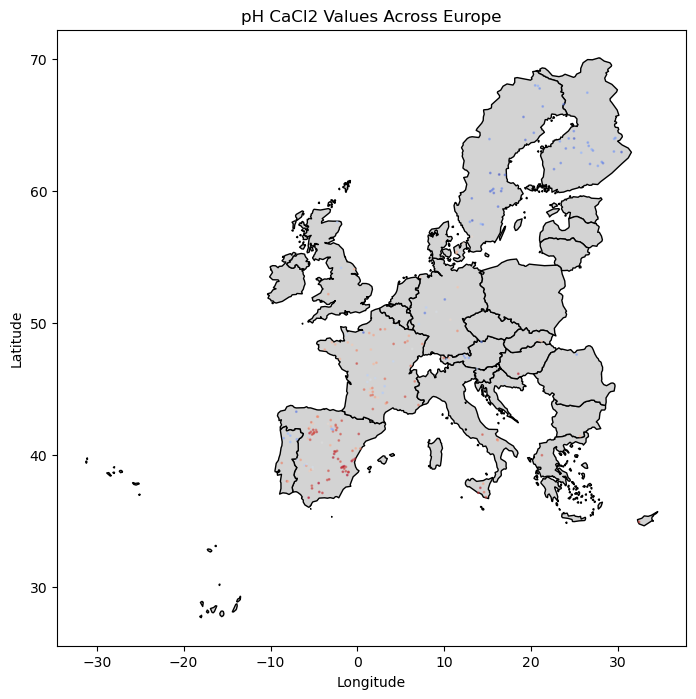

In [53]:
solution_function_string = run_test(geo_queries[6])

In [54]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	import pandas as pd
	# Filter the data to only include rows where pH_CaCl2 is not null and Depth is '0-10 cm'
	transformed_gdf = data_gdf.dropna(subset=['pH_CaCl2']).copy()
	transformed_gdf = transformed_gdf[transformed_gdf['Depth'] == '0-10 cm']
	# Create a new GeoDataFrame with only the required columns
	required_columns = ['geometry', 'POINTID', 'pH_CaCl2']
	transformed_gdf = transformed_gdf[required_columns]
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Plot the map of Europe with black borders and light gray fill color
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Overlay data from 'transformed_gdf' on top of the European map
	ax.scatter(x=[point.x for point in transformed_gdf.geometry], y=[point.y for point in transformed_gdf.geometry],
	           c=transformed_gdf['pH_CaCl2'], s=1, cmap='coolwarm', alpha=0.5)
	# 

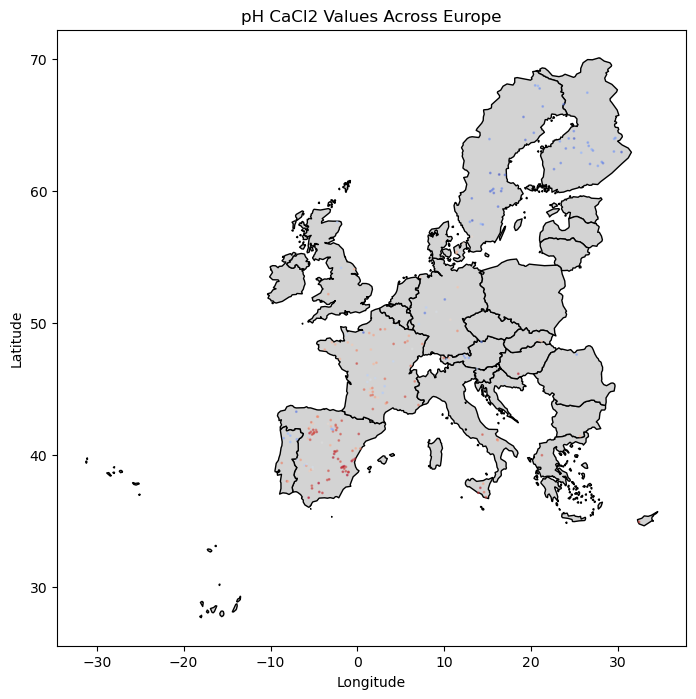

In [55]:
exec_solution(solution_function_string)

# 8. query

In [56]:
geo_queries[7]

"Can you show me a map of Europe marking only the locations with the highest potassium ('K') levels? Just highlight the top 10% of spots and save it as an image."

2025-02-17 22:01:23,905 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Select the 'K' column from data_gdf and calculate its 90th percentile value
max_k = data_gdf['K'].quantile(0.9)

# Filter data_gdf to include only rows where K is greater than or equal to max_k
transformed_gdf = data_gdf[data_gdf['K'] >= max_k]

# Save the transformed GeoDataFrame as a new variable called 'top_10_percent'
top_10_percent = transformed_gdf.copy()
```
2025-02-17 22:01:26,256 - Query finished successfully, response: 
map
2025-02-17 22:01:34,977 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Get the top 10% of K levels from transformed_gdf and sort them in descending order
top_k_values = sorted(transformed_gdf['K'].unique())[-int(0.1*len(transformed_gdf))]

# Filter 'transformed_gdf' to include only locations with potassium ('K') values within the top 10%
filtered_df = transformed_gdf[transformed_gdf['K'].isi

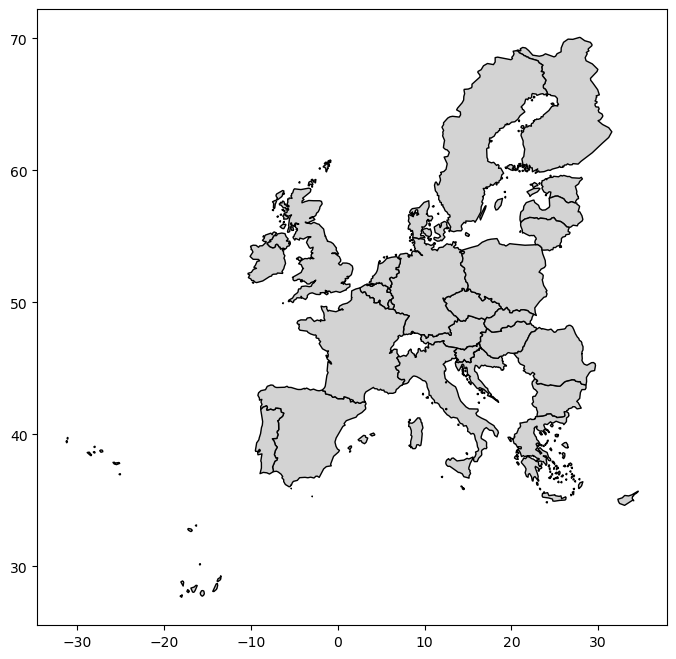

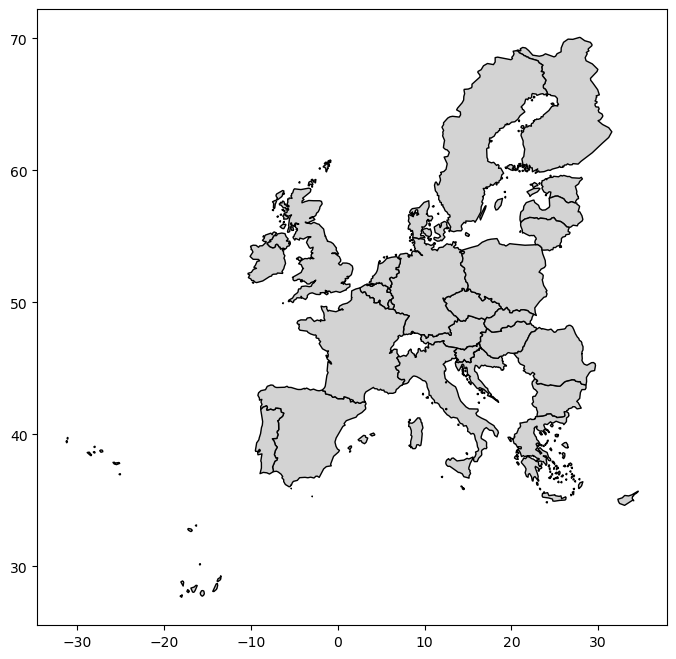

In [57]:
solution_function_string = run_test(geo_queries[7])

In [58]:
print(solution_function_string)

None


In [59]:
exec_solution(solution_function_string)

No solution provided.


# 9. query

In [60]:
geo_queries[8]

'Could you make a map showing where soil pH_H2O levels in Europe are acidic versus basic? Mark acidic spots in red and basic spots in blue, and save it as an image.'

2025-02-17 22:02:17,599 - Query finished successfully, response: 
```python
# Filter the data to include only rows where pH_H2O is less than 7 (acidic) or greater than 7 (basic)
transformed_gdf = data_gdf[(data_gdf['pH_H2O'] < 7) | (data_gdf['pH_H2O'] > 7)]

# Create a new column 'soil_type' based on the pH_H2O values
transformed_gdf['soil_type'] = np.where(transformed_gdf['pH_H2O'] < 7, 'acidic', 'basic')

# Map acidic spots to red and basic spots to blue for visualization (not shown in this code snippet)
# transformed_gdf['color'] = np.where(transformed_gdf['soil_type'] == 'acidic', 'red', 'blue')
```
2025-02-17 22:02:20,001 - Query finished successfully, response: 
map
2025-02-17 22:02:27,583 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map of Europe using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Define a fun

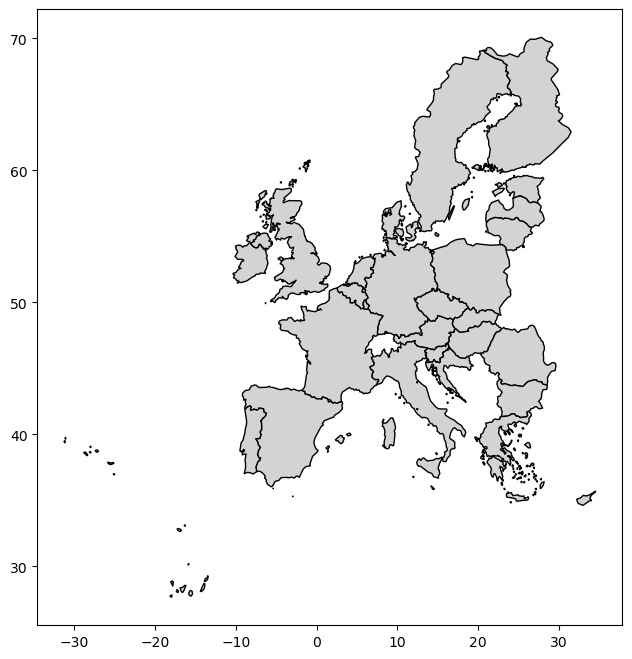

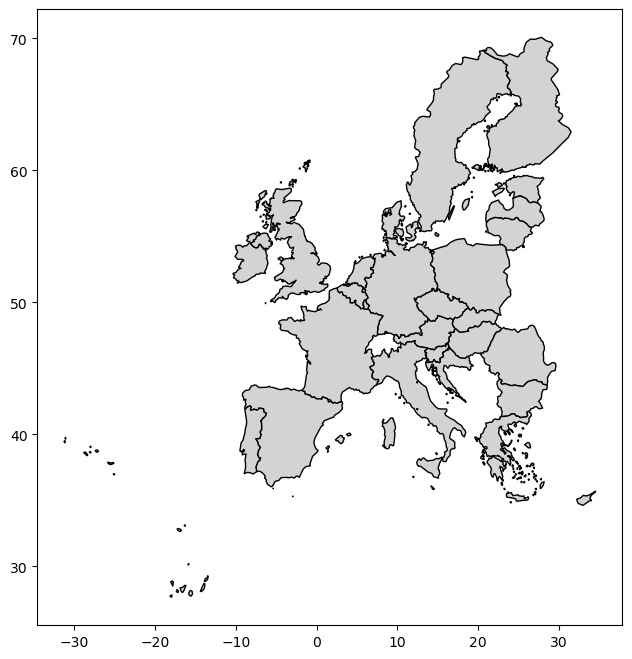

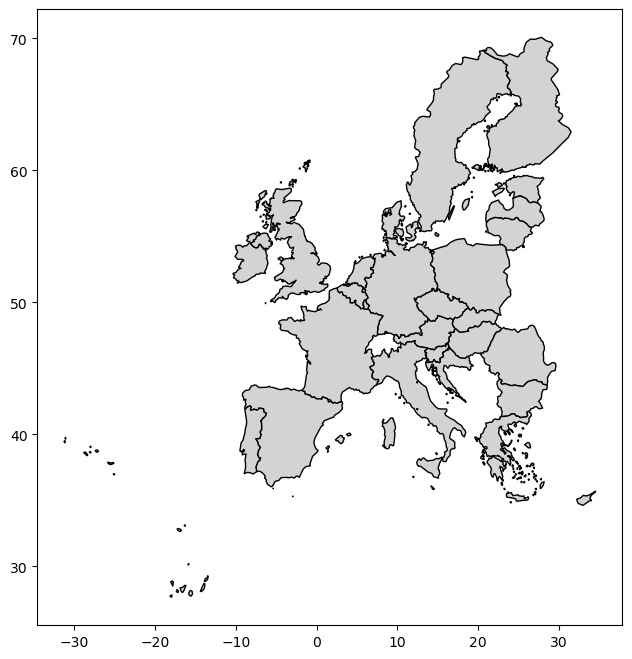

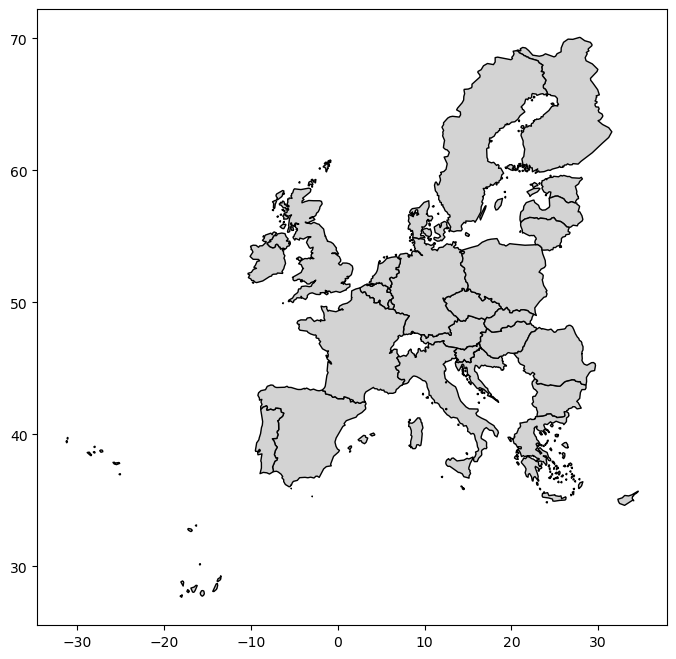

In [61]:
solution_function_string = run_test(geo_queries[8])

In [62]:
print(solution_function_string)

None


In [63]:
exec_solution(solution_function_string)

No solution provided.


# 10. query

In [64]:
geo_queries[9]

"Can you create a colorful map showing different types of soil by 'LC0_Desc' across Europe? I'd like each soil type marked in a different color and saved as an image."

2025-02-17 22:03:21,266 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to include only rows where LC0_Desc is not null and equals 'Woodland'
transformed_gdf = data_gdf[data_gdf['LC0_Desc'].notnull() & (data_gdf['LC0_Desc'] == 'Woodland')]

# Create a new column 'color' based on the unique values in LC0_Desc
transformed_gdf['color'] = transformed_gdf['LC0_Desc']

# Map each soil type to a different color using a dictionary
soil_colors = {'Cropland': '#FF0000',  # Red for Cropland
               'Grassland': '#008000',  # Green for Grassland
               'Bareland': '#808080',   # Gray for Bareland
               'Shrubland': '#FFFF00',  # Yellow for Shrubland
               'Artificial land': '#800080',  # Purple for Artificial land
               'Wetlands': '#0000FF',    # Blue for Wetlands
               'Water': '#C0C0C0'}     # Light Gray for Water

# Apply the color mapping to the transformed_gdf
transforme

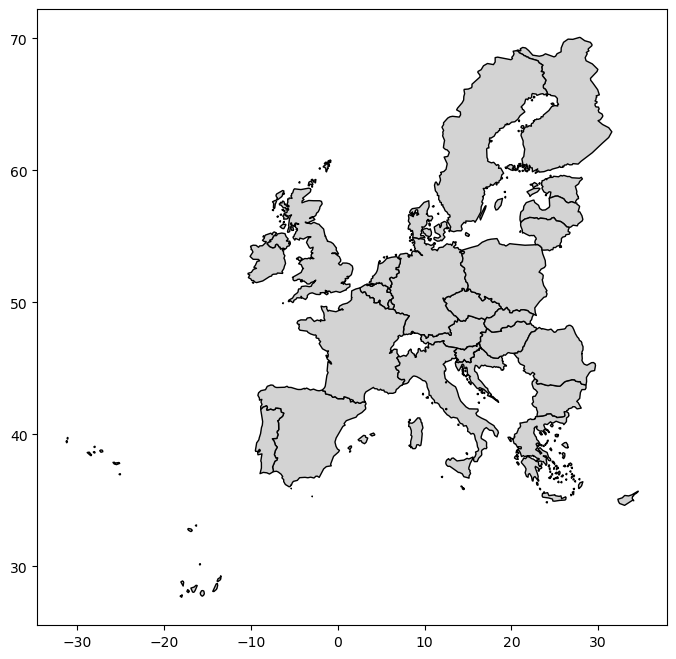

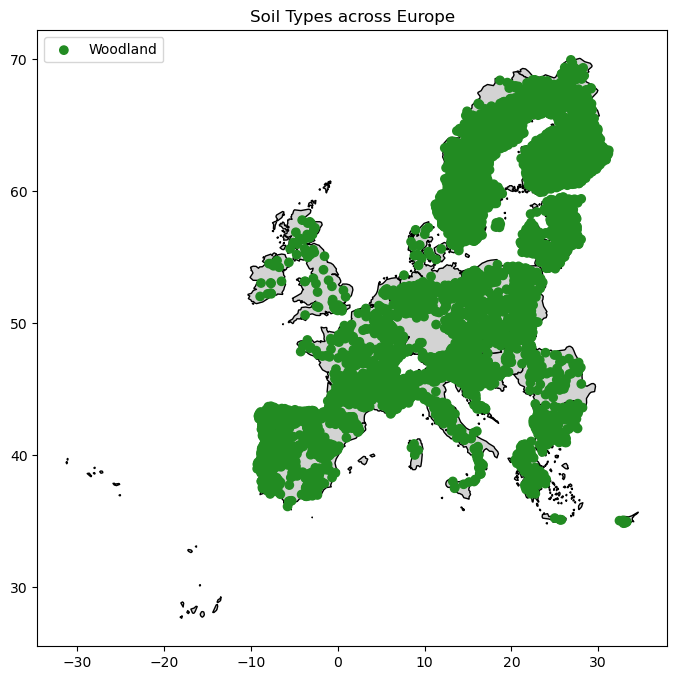

In [65]:
solution_function_string = run_test(geo_queries[9])

In [66]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary libraries
	import pandas as pd
	# Filter the data to include only rows where LC0_Desc is not null and equals 'Woodland'
	transformed_gdf = data_gdf[data_gdf['LC0_Desc'].notnull() & (data_gdf['LC0_Desc'] == 'Woodland')]
	# Create a new column 'color' based on the unique values in LC0_Desc
	transformed_gdf['color'] = transformed_gdf['LC0_Desc']
	# Map each soil type to a different color using a dictionary
	soil_colors = {'Cropland': '#FF0000',  # Red for Cropland
	               'Grassland': '#008000',  # Green for Grassland
	               'Bareland': '#808080',   # Gray for Bareland
	               'Shrubland': '#FFFF00',  # Yellow for Shrubland
	               'Artificial land': '#800080',  # Purple for Artificial land
	               'Wetlands': '#0000FF',    # Blue for Wetlands
	               'Water': '#C0C0C0'}     # Light Gray for Water
	# Apply the color mapping to the transformed_gdf
	trans

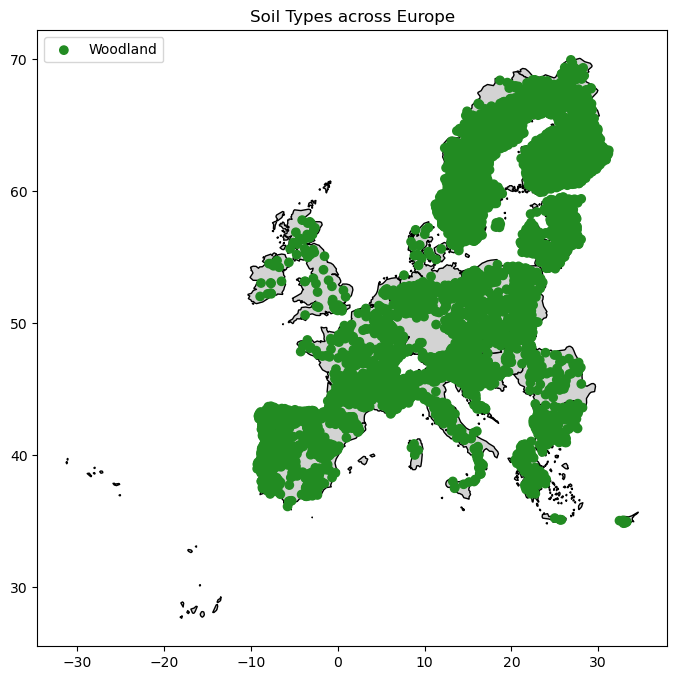

In [67]:
exec_solution(solution_function_string)

### Testing on all queries

Processing 10 geo queries

QUERY:  Can you plot the locations of all points where the pH_CaCl2 is greater than 6 on a map, and save the image as a PNG file?



2025-02-17 22:59:18,808 - Query finished successfully, response: 
Here is the Python code that filters and transforms the data based on your requirements:

```python
transformed_gdf = data_gdf.copy()

# Filter points where pH_CaCl2 is greater than 6
filtered_points = transformed_gdf[transformed_gdf['pH_CaCl2'] > 6]

# Save the filtered GeoDataFrame to a new variable for plotting later if needed
plotting_data = filtered_points

# Store the result in 'transformed_gdf'
transformed_gdf = filtered_points.copy()
```

This code filters out points where pH_CaCl2 is greater than or equal to 6 and stores them in `filtered_points`. It also creates a copy of this data for potential plotting later. The transformed GeoDataFrame, which now contains only the filtered rows, is stored back into 'transformed_gdf'.
2025-02-17 22:59:24,926 - Query finished successfully, response: 
map
2025-02-17 22:59:33,047 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8))
europe_


QUERY:  Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20 on the map, and save the map as a png.



2025-02-17 22:59:42,043 - Query finished successfully, response: 
```python
transformed_gdf = data_gdf.copy()
filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
final_transformed_gdf = filtered_data[filtered_data['OC'] > 20]
```
2025-02-17 22:59:47,964 - Query finished successfully, response: 
map
2025-02-17 22:59:56,617 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
transformed_gdf[transformed_gdf['LC0_Desc'].isin(['Grassland', 'Woodland']) & transformed_gdf['OC'] > 20].plot(ax=ax)
ax.set_title('Locations of Grassland and Woodland with OC>20 on a map')
plt.savefig('grassland_woodland_map.png')
```
2025-02-17 22:59:56,749 - Error while running visualize query: aspect must be finite and positive 
2025-02-17 23:00:05,878 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8), 


QUERY:  Can you plot the locations where LC0_Desc=Woodland on the map, and save the it as a PNG file?



...

2025-02-17 23:02:32,545 - Query finished successfully, response: 
```python
transformed_gdf = data_gdf.copy()
data_gdf['K_above_median'] = (data_gdf['K'] > stats.scoreatpercentile(data_gdf['K'], 90))
```
2025-02-17 23:02:37,985 - Query finished successfully, response: 
map
2025-02-17 23:02:45,648 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
transformed_gdf[transformed_gdf['K_above_median'] == True].plot(ax=ax, marker='o', markersize=1)
plt.savefig('high_potassium_map.png')
```
2025-02-17 23:02:45,912 - Using default tokenizer.



QUERY:  Could you make a map showing where soil pH_H2O levels in Europe are acidic versus basic? Mark acidic spots in red and basic spots in blue, and save it as an image.



2025-02-17 23:02:53,314 - Query finished successfully, response: 
```python
transformed_gdf = data_gdf.copy()
data_gdf['pH_H2O_category'] = pd.cut(data_gdf['pH_H2O'], bins=[0, 7, 14], labels=['acidic', 'basic'])
```
2025-02-17 23:02:58,821 - Query finished successfully, response: 
map
2025-02-17 23:03:07,575 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
transformed_gdf['pH_H2O_category'] = transformed_gdf['pH_H2O'].apply(lambda x: 'acidic' if x < 7 else 'basic')
transformed_gdf.plot(ax=ax, column='pH_H2O_category', legend=True, markersize=1)
plt.savefig('ph_map.png')
```
2025-02-17 23:03:10,176 - Using default tokenizer.



QUERY:  Can you create a colorful map showing different types of soil by 'LC0_Desc' across Europe? I'd like each soil type marked in a different color and saved as an image.



2025-02-17 23:03:18,872 - Query finished successfully, response: 
```python
transformed_gdf = data_gdf.copy()
data_gdf['LC0_Color'] = pd.Categorical(data_gdf['LC0_Desc']).codes
color_map = {1: 'red', 2: 'green', 3: 'blue', 4: 'yellow', 5: 'orange'}
transformed_gdf['Color'] = data_gdf['LC0_Color'].map(color_map)
```
2025-02-17 23:03:24,519 - Query finished successfully, response: 
map
2025-02-17 23:03:32,562 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
transformed_gdf['LC0_Desc'].astype('category').cat.set_categories(transformed_gdf['LC0_Desc'], ordered=True).plot(ax=ax, column='Color', legend=True)
plt.savefig('soil_map.png')
```
2025-02-17 23:03:32,683 - Error while running visualize query: Categorical categories must be unique
2025-02-17 23:03:41,110 - Query finished successfully, response: 
```python
fig, ax = plt.subplots(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='bla

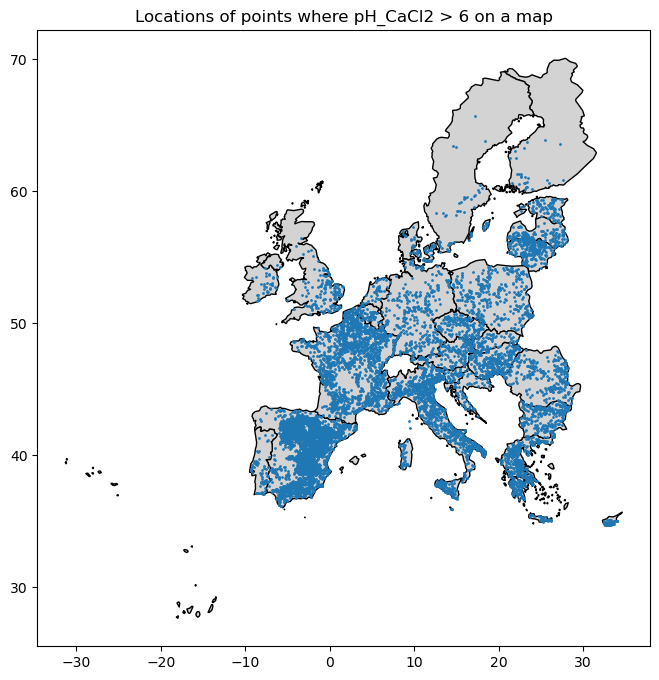

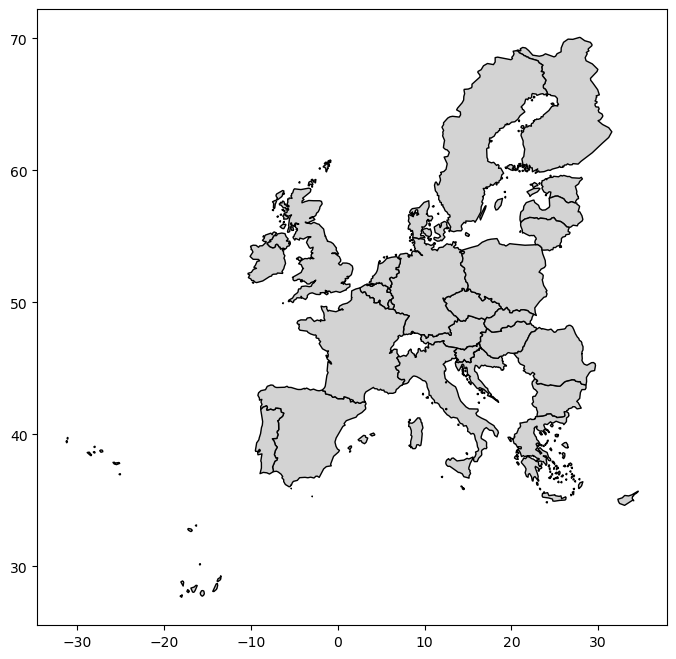

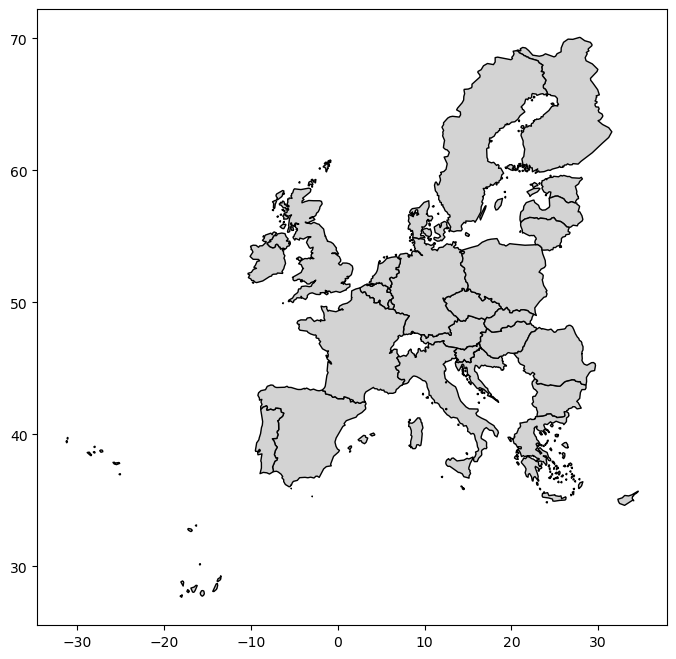

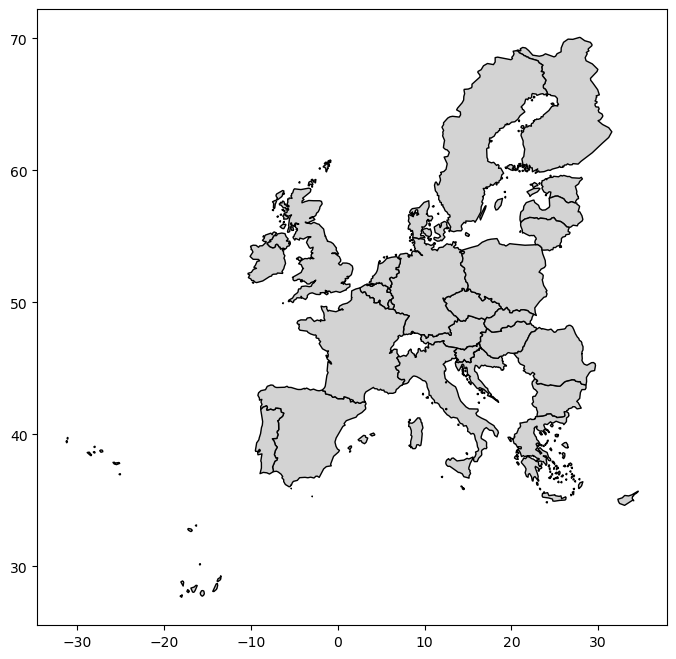

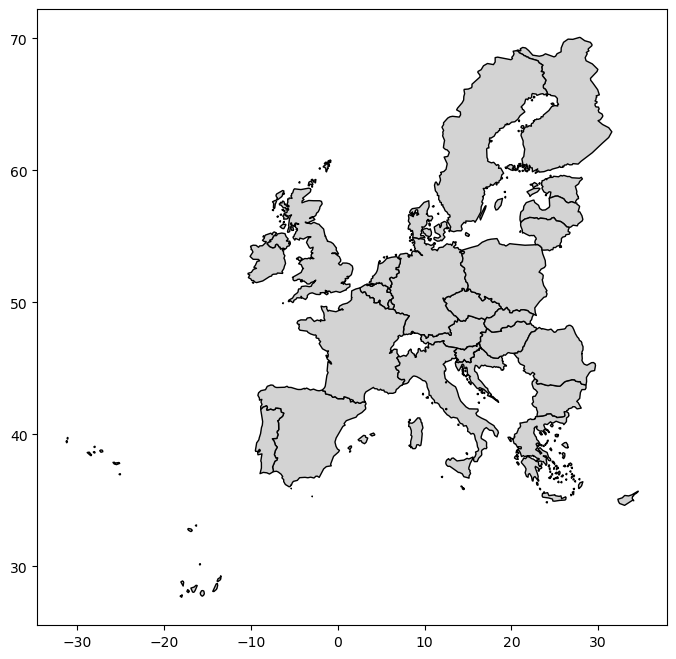

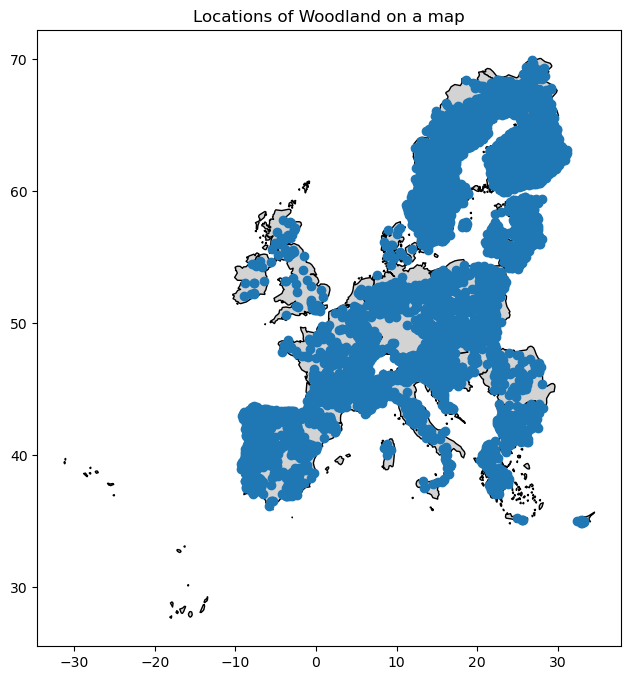

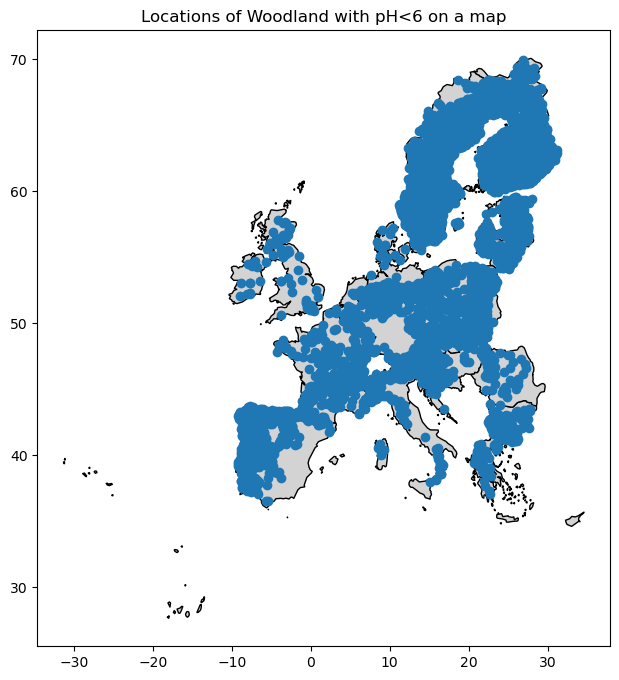

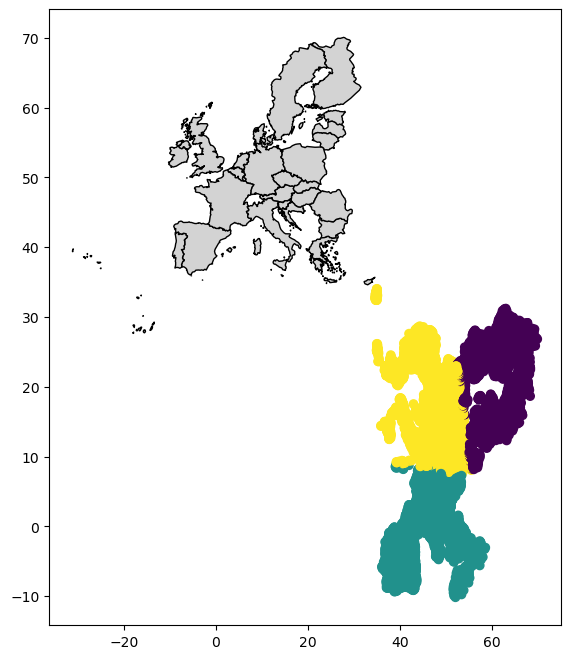

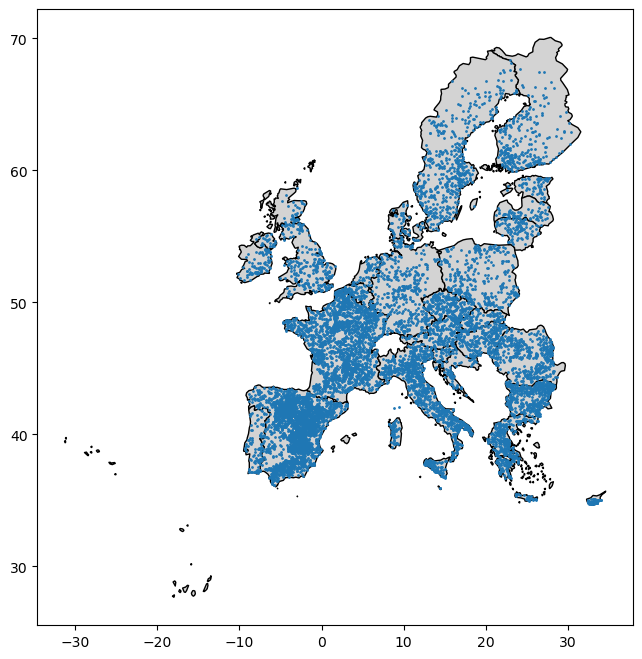

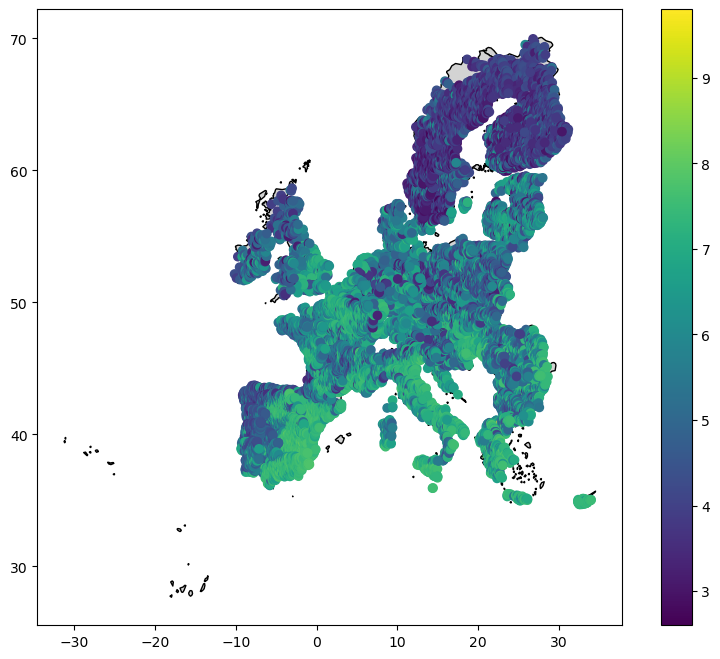

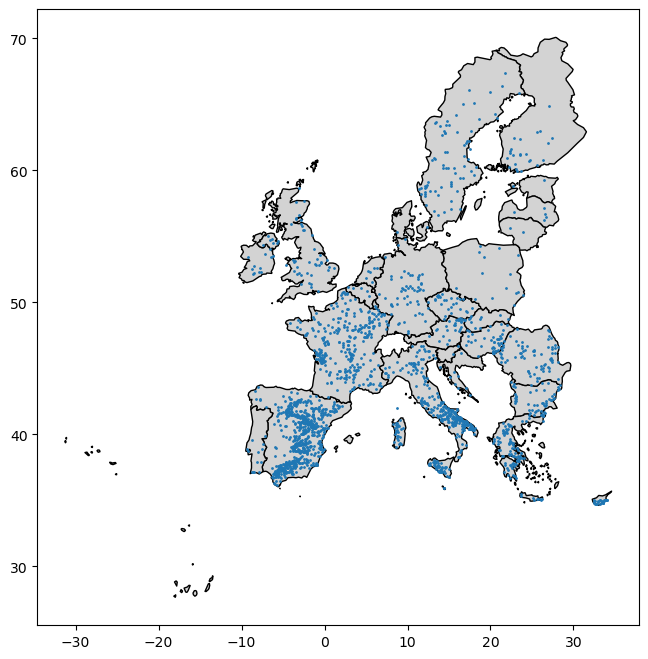

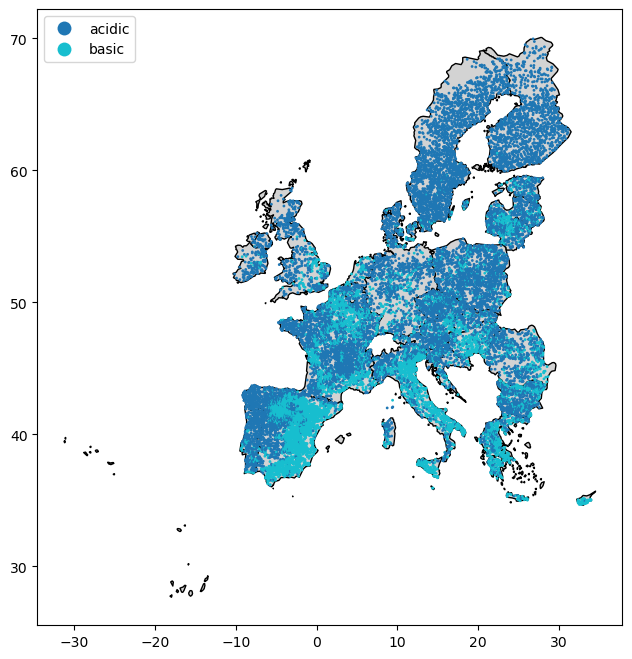

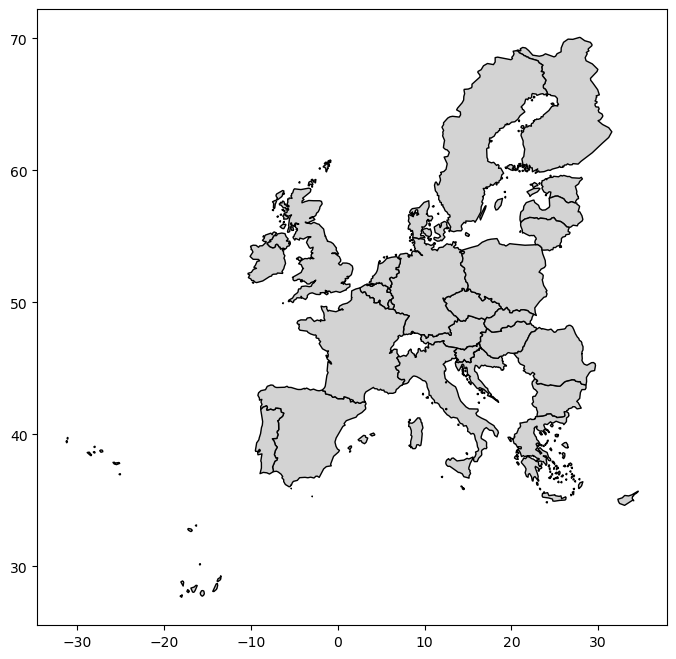

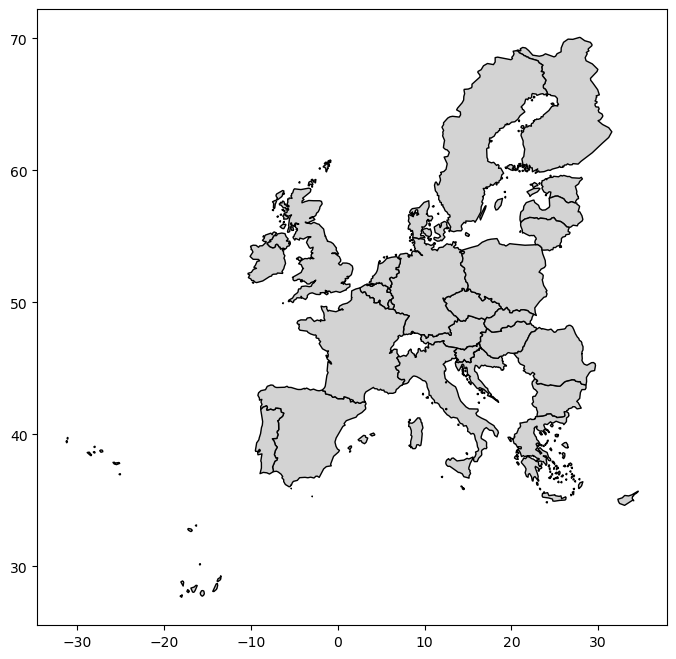

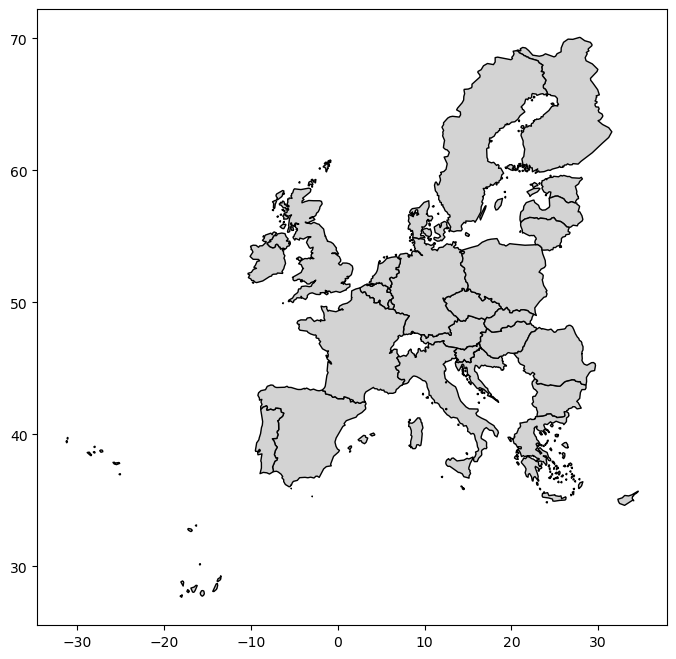

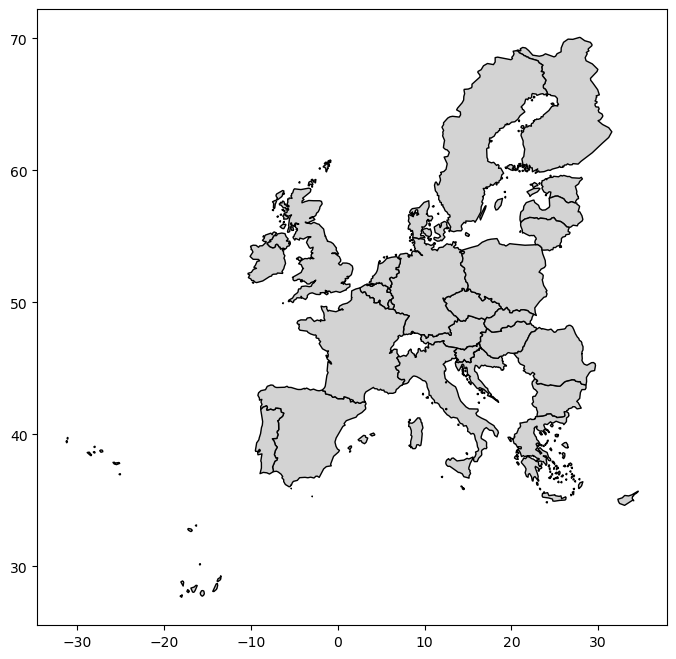

In [69]:
for query_type in ['geo']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    print(f"Processing {query_count} {query_type} queries")
    os.makedirs(f"{BASE_GENERATED_DIR}{query_type}", exist_ok=True)
    os.makedirs(f"{BASE_METRICS_DIR}{query_type}", exist_ok=True)
    
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        print()
        print("QUERY: ", query, end='\n\n')
        correct_result = open(f"{BASE_CORRECT_RESULT_DIR}{query_type}/{file}", 'r').read()
        
        generated_result = run_test(query)
        
        if not generated_result is None:
            open(f"{BASE_GENERATED_DIR}{query_type}/{query_index}.txt", 'w').write(generated_result)
            
            metrics = evaluate_metrics(correct_result, clean_python_code(generated_result))
            metrics.MODEL_ID = model_id
            with open(f"{BASE_METRICS_DIR}{query_type}/{query_index}.json", 'w') as f:
                json.dump(metrics.model_dump(), f, indent=4)